### Demand forecasting
* weekly arrivals per hotel, the bookings that arrived and were not cancelled, rolling backtest of seasonal naive, seasonal naive with year on year growth, damped exponential smoothing, fourier regression with arima errors, a pickup model on the rooms already on the books, a direct boosted model per horizon on last year's week, the recent level, the rooms on the books and the calendar, and their means
* autocorrelation and stationarity diagnostics of the series and of the model residuals
* learning curves per origin, in sample error of the fitted model against its forecast error on the horizon
* nowcast of monthly hotel nights in Portugal for the months Eurostat has not published, with a test of Wikipedia attention as a leading signal
* exports the forecast, the backtest, the learning curves and the nowcast for the dashboard

In [1]:
import os
import json
import datetime
import warnings
import numpy as np
import pandas as pd
import lightgbm as lgb
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
warnings.filterwarnings("ignore")

ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
PARQUET_PATH = os.path.join(ROOT_DIR, "data", "parquet", "bookings.parquet")
PAGEVIEWS_PATH = os.path.join(ROOT_DIR, "data", "parquet", "pageviews.parquet")
EUROSTAT_PATH = os.path.join(ROOT_DIR, "data", "parquet", "eurostat.parquet")
MODELS_DIR = os.path.join(ROOT_DIR, "data", "models")
hotel_colors = {"City Hotel": "steelblue", "Resort Hotel": "darkcyan"}
replay_shift_days = 0
origin_date = pd.Timestamp(datetime.date.today() - datetime.timedelta(days=replay_shift_days))
horizon_weeks = 8
min_history_weeks = 52
min_origins = 3
growth_window = 6
max_origins = 52

In [2]:
# weekly arrivals per hotel counting the bookings that arrived and were not cancelled, open bookings past their arrival date included, plus the bookings frame for the pickup model
def weekly_arrivals(path):
    frame = pd.read_parquet(path)
    for col in ["arrival_date", "booking_date", "leave_books_date"]:
        frame[col] = pd.to_datetime(frame[col])
    frame["week"] = frame["arrival_date"].dt.to_period("W-SUN").dt.end_time.dt.normalize()
    arrived = frame["arrival_date"] <= origin_date
    not_cancelled = (frame["is_canceled"] == 0) | (frame["reservation_status"] == "Open")
    weekly = frame[arrived & not_cancelled].groupby(["hotel", "week"]).size().rename("arrivals").reset_index()
    return weekly, frame

In [3]:
# seasonal naive forecast, the value 52 weeks earlier
def forecast_seasonal_naive(history, steps, extra=None):
    values = history["arrivals"].values
    out = [values[len(values) - 52 + i] if len(values) >= 52 else values[-1] for i in range(steps)]
    return np.array(out, dtype=float)

In [4]:
# seasonal naive with growth, the value 52 weeks earlier times the ratio of the last eight weeks to the same eight weeks a year earlier, bounded
def forecast_seasonal_naive_growth(history, steps, extra=None):
    values = history["arrivals"].astype(float).values
    base = forecast_seasonal_naive(history, steps, extra)
    if len(values) < 60:
        return base
    recent = values[-8:].sum()
    year_ago = values[-60:-52].sum()
    growth = float(np.clip(recent / max(year_ago, 1.0), 0.8, 1.25))
    return base * growth

In [5]:
# damped holt winters, yearly seasonality only when two full cycles exist
def forecast_ets(history, steps, extra=None):
    values = history["arrivals"].astype(float).values
    if len(values) < 104:
        model = ExponentialSmoothing(values, trend="add", damped_trend=True).fit()
    else:
        model = ExponentialSmoothing(values, trend="add", seasonal="add", seasonal_periods=52, damped_trend=True).fit()
    return np.clip(model.forecast(steps), 0, None)

In [6]:
# rooms already on the books at the origin for each target week and last year's pickup ratio for the same weeks ahead
def pickup_inputs(frame, hotel, origin, target_weeks):
    part = frame[(frame["hotel"] == hotel) & (frame["booking_date"] <= origin) & (frame["leave_books_date"] > origin) & frame["week"].isin(target_weeks)]
    otb = part.groupby("week").size().reindex(target_weeks).fillna(0).values
    ratios = []
    for h in range(1, len(target_weeks) + 1):
        week_ly = origin - pd.Timedelta(weeks=52) + pd.Timedelta(weeks=h)
        rows = frame[(frame["hotel"] == hotel) & (frame["week"] == week_ly)]
        final = float((rows["is_canceled"] == 0).sum())
        otb_ly = float(((rows["booking_date"] <= origin - pd.Timedelta(weeks=52)) & (rows["leave_books_date"] > origin - pd.Timedelta(weeks=52))).sum())
        ratios.append(final / otb_ly if otb_ly >= 5 else 1.0)
    ratios = np.clip(np.array(ratios), 0.5, 3.0)
    smoothed = pd.Series(ratios).rolling(3, center=True, min_periods=1).median().values
    return otb, smoothed

In [7]:
# rooms on the books per target week for every origin one to eight weeks before it, from the bookings of that week: booked by the origin and not yet cancelled
def otb_table(frame, hotel, steps):
    part = frame[frame["hotel"] == hotel]
    rows = []
    for week, group in part.groupby("week"):
        booked = group["booking_date"].values.astype("datetime64[D]")
        leaves = group["leave_books_date"].values.astype("datetime64[D]")
        final = int((group["is_canceled"] == 0).sum())
        for h in range(1, steps + 1):
            origin = np.datetime64((week - pd.Timedelta(weeks=h)).date())
            rows.append({"week": week, "h": h, "otb": int(((booked <= origin) & (leaves > origin)).sum()), "final": final})
    return pd.DataFrame(rows)

In [8]:
# training and forecast rows of the direct boosted model: one row per origin and horizon with last year's arrivals of the target week and its neighbours, the recent level and year on year growth at the origin, the rooms already on the books for the target week and last year's pickup ratio at the same lead, the horizon and the yearly cycle
def gbm_rows(series, otb, steps):
    values = series["arrivals"].astype(float).values
    weeks = series["week"].values
    week_pos = {w: i for i, w in enumerate(weeks)}
    otb_map = {(r.week, r.h): (r.otb, r.final) for r in otb.itertuples(index=False)}
    rows = []
    for origin in range(60, len(series) + steps):
        hist = values[:origin]
        level4 = hist[-4:].mean()
        yoy = float(np.clip(hist[-8:].sum() / max(hist[-60:-52].sum(), 1.0), 0.7, 1.4))
        for h in range(1, steps + 1):
            t = origin + h - 1
            week = weeks[-1] + np.timedelta64(7 * (t - len(weeks) + 1), "D") if t >= len(weeks) else weeks[t]
            lag52 = values[t - 52] if t - 52 < len(values) and t >= 52 else np.nan
            lag52n = np.nanmean([values[k] for k in (t - 53, t - 52, t - 51) if 0 <= k < len(values)]) if t >= 53 else np.nan
            lag104 = values[t - 104] if t >= 104 and t - 104 < len(values) else np.nan
            o, f = otb_map.get((pd.Timestamp(week), h), (np.nan, np.nan))
            week_ly = pd.Timestamp(week) - pd.Timedelta(weeks=52)
            o_ly, f_ly = otb_map.get((week_ly, h), (np.nan, np.nan))
            ratio = f_ly / o_ly if o_ly and o_ly >= 5 else np.nan
            woy = pd.Timestamp(week).isocalendar()[1]
            rows.append({"origin_pos": origin, "week": pd.Timestamp(week), "h": h, "lag52": lag52, "lag52n": lag52n, "lag104": lag104, "level4": level4, "yoy": yoy, "otb": o, "ratio_ly": ratio, "pickup": o * ratio if ratio == ratio and o == o else np.nan, "woy_sin": np.sin(2 * np.pi * woy / 52), "woy_cos": np.cos(2 * np.pi * woy / 52), "target": values[t] if t < len(values) else np.nan})
    return pd.DataFrame(rows)

In [9]:
# regularised boosted model fit on the rows whose target week is known at the origin, early stopping on the last 26 origin weeks of those rows
gbm_params = {"objective": "regression", "metric": "l1", "learning_rate": 0.05, "num_leaves": 15, "min_data_in_leaf": 40, "feature_fraction": 0.7, "bagging_fraction": 0.8, "bagging_freq": 1, "lambda_l2": 10.0, "verbose": -1, "num_threads": 3, "seed": 7}
gbm_features = ["lag52", "lag52n", "lag104", "level4", "yoy", "otb", "ratio_ly", "pickup", "h", "woy_sin", "woy_cos", "hotel_code"]


def fit_gbm(rows, origin_pos):
    train = rows[(rows["origin_pos"] + rows["h"] - 1 < origin_pos) & rows["target"].notna()]
    cut = train["origin_pos"].max() - 26
    a, b = train[train["origin_pos"] <= cut], train[train["origin_pos"] > cut]
    model = lgb.train(gbm_params, lgb.Dataset(a[gbm_features], label=a["target"]), num_boost_round=2000, valid_sets=[lgb.Dataset(b[gbm_features], label=b["target"])], callbacks=[lgb.early_stopping(50, verbose=False)])
    return model


# forecast of the direct boosted model for one origin: the eight rows of that origin
def forecast_gbm(rows, model, origin_pos, steps):
    part = rows[(rows["origin_pos"] == origin_pos)].sort_values("h").head(steps)
    return np.clip(model.predict(part[gbm_features], num_iteration=model.best_iteration), 0, None)

In [10]:
# regression on fourier terms of the yearly cycle with arima errors, estimable with one cycle of history
def fourier_terms(index, k=3):
    woy = pd.Index(index).isocalendar().week.astype(float).values
    cols = {}
    for j in range(1, k + 1):
        cols["s" + str(j)] = np.sin(2 * np.pi * j * woy / 52)
        cols["c" + str(j)] = np.cos(2 * np.pi * j * woy / 52)
    cols["t"] = np.arange(len(index))
    return pd.DataFrame(cols, index=index)


def forecast_fourier_arima(history, steps, extra=None):
    values = history["arrivals"].astype(float).values
    if len(values) < 45:
        return forecast_ets(history, steps)
    index = pd.DatetimeIndex(history["week"])
    future_index = pd.date_range(index[-1] + pd.Timedelta(weeks=1), periods=steps, freq="W-SUN")
    x_all = fourier_terms(index.append(future_index))
    model = SARIMAX(values, exog=x_all.iloc[:len(values)].values, order=(1, 0, 1), trend="c", enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=300)
    return np.clip(model.forecast(steps, exog=x_all.iloc[len(values):].values), 0, None)

In [11]:
# pickup model, arrivals on the books at the origin scaled by last year's pickup ratio
def forecast_pickup(history, steps, extra):
    return np.clip(extra["otb"][:steps] * extra["ratios"][:steps], 0, None)


# mean of exponential smoothing, fourier arima and pickup
def forecast_ensemble(history, steps, extra):
    return np.mean([forecast_ets(history, steps), forecast_fourier_arima(history, steps), forecast_pickup(history, steps, extra)], axis=0)


# mean of exponential smoothing and pickup
def forecast_mean_ets_pickup(history, steps, extra):
    return np.mean([forecast_ets(history, steps), forecast_pickup(history, steps, extra)], axis=0)


# mean absolute percentage error ignoring zero actuals
def mape(actual, forecast):
    actual = np.asarray(actual, dtype=float)
    forecast = np.asarray(forecast, dtype=float)
    mask = actual > 0
    return float(np.mean(np.abs(actual[mask] - forecast[mask]) / actual[mask]))

In [12]:
# in sample values of the seasonal naive method, the arrivals 52 weeks earlier, the first year repeated from itself
def fitted_seasonal_naive(history):
    values = history["arrivals"].values.astype(float)
    out = np.roll(values, 52)
    out[:52] = values[:52]
    return out

In [13]:
# in sample fitted values of the damped exponential smoothing model
def fitted_ets(history):
    values = history["arrivals"].astype(float).values
    if len(values) < 104:
        model = ExponentialSmoothing(values, trend="add", damped_trend=True).fit()
    else:
        model = ExponentialSmoothing(values, trend="add", seasonal="add", seasonal_periods=52, damped_trend=True).fit()
    return np.clip(model.fittedvalues, 0, None)

In [14]:
# in sample fitted values of the fourier regression with arima errors
def fitted_fourier_arima(history):
    values = history["arrivals"].astype(float).values
    if len(values) < 45:
        return fitted_ets(history)
    index = pd.DatetimeIndex(history["week"])
    model = SARIMAX(values, exog=fourier_terms(index).values, order=(1, 0, 1), trend="c", enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=300)
    return np.clip(model.fittedvalues, 0, None)

In [15]:
# train against test error per origin over the last backtest origins, in sample mape of the fitted model over the last 52 weeks of the training window against the mape of its forecast on the horizon
def learning_curve(weekly, frame, hotel, min_history, steps):
    series = weekly[weekly["hotel"] == hotel].reset_index(drop=True)
    methods = {"seasonal_naive": (forecast_seasonal_naive, fitted_seasonal_naive), "seasonal_naive_growth": (forecast_seasonal_naive_growth, fitted_seasonal_naive), "ets": (forecast_ets, fitted_ets), "fourier_arima": (forecast_fourier_arima, fitted_fourier_arima)}
    grows = gbm_rows(series, otb_table(frame, hotel, steps), steps)
    grows["hotel_code"] = 1 if hotel == "City Hotel" else 0
    rows = []
    last_origin = len(series) - steps
    for origin in range(max(min_history, last_origin + 1 - max_origins), last_origin + 1):
        history = series.iloc[:origin]
        actual = series.iloc[origin:origin + steps]["arrivals"].values
        for name, (forecast, fitted) in methods.items():
            train_mape = mape(history["arrivals"].values[-52:], fitted(history)[-52:])
            test_mape = mape(actual, forecast(history, steps))
            rows.append({"hotel": hotel, "origin": str(series.iloc[origin - 1]["week"].date()), "method": name, "train_mape": round(train_mape, 4), "test_mape": round(test_mape, 4)})
        model = fit_gbm(grows, origin)
        recent = grows[(grows["origin_pos"] + grows["h"] - 1 < origin) & (grows["origin_pos"] + grows["h"] - 1 >= origin - 52) & grows["target"].notna()]
        train_mape = mape(recent["target"].values, model.predict(recent[gbm_features], num_iteration=model.best_iteration))
        rows.append({"hotel": hotel, "origin": str(series.iloc[origin - 1]["week"].date()), "method": "gbm_direct", "train_mape": round(train_mape, 4), "test_mape": round(mape(actual, forecast_gbm(grows, model, origin, steps)), 4)})
    return pd.DataFrame(rows)

In [16]:
# learning curves per method, in sample against forecast mape by origin
def plot_learning_curve(curve, hotel, steps):
    part = curve[curve["hotel"] == hotel]
    methods = part["method"].unique()
    fig, axes = plt.subplots(1, len(methods), figsize=(6 * len(methods), 3.5), sharey=True)
    for ax, name in zip(np.atleast_1d(axes), methods):
        m = part[part["method"] == name]
        ax.plot(pd.to_datetime(m["origin"]), m["train_mape"], marker="o", color="blue", label="train, in sample")
        ax.plot(pd.to_datetime(m["origin"]), m["test_mape"], marker="o", color="red", label="test, " + str(steps) + " weeks ahead")
        ax.set_title(name)
        ax.set_xlabel("origin")
        ax.legend()
    np.atleast_1d(axes)[0].set_ylabel("mape")
    fig.suptitle("Learning curves, " + hotel)
    plt.tight_layout()
    plt.show()

In [17]:
# rolling origin backtest of all methods for one hotel over the last origins with at least a year of history, each base method fit once per origin and the means derived from them; the boosted model is refit at every origin on rows whose target week is already known
def backtest(weekly, frame, hotel, min_history, steps):
    series = weekly[weekly["hotel"] == hotel].reset_index(drop=True)
    grows = gbm_rows(series, otb_table(frame, hotel, steps), steps)
    grows["hotel_code"] = 1 if hotel == "City Hotel" else 0
    rows = []
    last_origin = len(series) - steps
    for origin in range(max(min_history, last_origin + 1 - max_origins), last_origin + 1):
        history = series.iloc[:origin]
        target_weeks = list(series.iloc[origin:origin + steps]["week"])
        otb, ratios = pickup_inputs(frame, hotel, history["week"].iloc[-1], target_weeks)
        extra = {"otb": otb, "ratios": ratios}
        actual = series.iloc[origin:origin + steps]["arrivals"].values
        base = {"seasonal_naive": forecast_seasonal_naive(history, steps, extra), "seasonal_naive_growth": forecast_seasonal_naive_growth(history, steps, extra), "ets": forecast_ets(history, steps, extra), "fourier_arima": forecast_fourier_arima(history, steps, extra), "pickup": forecast_pickup(history, steps, extra)}
        base["gbm_direct"] = forecast_gbm(grows, fit_gbm(grows, origin), origin, steps)
        base["mean_ets_pickup"] = np.mean([base["ets"], base["pickup"]], axis=0)
        base["ensemble"] = np.mean([base["ets"], base["fourier_arima"], base["pickup"]], axis=0)
        for name, forecast in base.items():
            rows.append({"hotel": hotel, "origin": series.iloc[origin - 1]["week"], "method": name, "mape": mape(actual, forecast)})
    return pd.DataFrame(rows)

In [18]:
# plot the last backtest origin forecasts against actuals
def plot_last_origin(weekly, frame, hotel, steps):
    series = weekly[weekly["hotel"] == hotel].reset_index(drop=True)
    origin = len(series) - steps
    history = series.iloc[:origin]
    actual = series.iloc[origin:]
    otb, ratios = pickup_inputs(frame, hotel, history["week"].iloc[-1], list(actual["week"]))
    extra = {"otb": otb, "ratios": ratios}
    plt.figure(figsize=(10, 4))
    plt.plot(series["week"].iloc[-60:], series["arrivals"].iloc[-60:], color="gray", label="actual")
    for name, fn, color in [("seasonal naive", forecast_seasonal_naive, "orange"), ("ets", forecast_ets, "green"), ("fourier arima", forecast_fourier_arima, "purple"), ("pickup", forecast_pickup, "red"), ("mean ets pickup", forecast_mean_ets_pickup, "blue")]:
        plt.plot(actual["week"], fn(history, steps, extra), color=color, label=name)
    plt.title("Weekly arrivals forecast, " + hotel)
    plt.ylabel("arrivals")
    plt.legend()
    plt.show()

In [19]:
# monthly pageview index across the main source market languages
def pageview_index(path):
    frame = pd.read_parquet(path)
    frame["date"] = pd.to_datetime(frame["date"])
    keep = frame[frame["project"].isin(["en.wikipedia", "de.wikipedia", "fr.wikipedia", "es.wikipedia", "it.wikipedia", "pt.wikipedia"])]
    keep = keep[keep["date"] < pd.Timestamp(datetime.date.today().replace(day=1))]
    monthly = keep.groupby([keep["project"], keep["date"].dt.to_period("M")])["views"].sum().unstack(0)
    monthly = monthly.fillna(monthly.mean())
    index = np.log(monthly).mean(axis=1)
    index.index = index.index.to_timestamp()
    return index.rename("pageview_index")

In [20]:
# monthly eurostat nights for one country
def eurostat_nights(path, geo):
    frame = pd.read_parquet(path)
    frame = frame[frame["geo"] == geo].copy()
    frame["month"] = pd.to_datetime(frame["month"])
    series = frame.set_index("month")["nights"].sort_index()
    return series

In [21]:
# nowcast frame with yearly log changes of nights and of the pageview index
def nowcast_frame(nights, index):
    frame = pd.DataFrame({"nights": nights})
    frame = frame.join(index, how="outer")
    frame["log_nights"] = np.log(frame["nights"])
    frame["log_nights_last_year"] = frame["log_nights"].shift(12)
    frame["growth"] = frame["log_nights"] - frame["log_nights_last_year"]
    frame["index_change"] = frame["pageview_index"] - frame["pageview_index"].shift(12)
    return frame

In [22]:
# regression of yearly growth in nights on the yearly change of the pageview index, post recovery months
def fit_pageview_test(frame, start):
    known = frame.dropna(subset=["growth", "index_change"])
    known = known[known.index >= start]
    x = sm.add_constant(known[["index_change"]])
    return sm.OLS(known["growth"], x).fit()

In [23]:
# trend nowcast, same month last year times the mean growth of the last published months
def fit_nowcast(frame, window):
    known = frame.dropna(subset=["growth"])
    growth = known["growth"].iloc[-window:].mean()
    pending = frame[frame["log_nights"].isna() & frame["log_nights_last_year"].notna()]
    pred = np.exp(pending["log_nights_last_year"] + growth)
    return growth, pred

In [24]:
# rolling check of the trend nowcast and the plain same month last year on the last published months
def nowcast_backtest(frame, window, months=12):
    known = frame.dropna(subset=["growth"])
    errors = []
    naive = []
    for month in known.index[-months:]:
        train = known[known.index < month]
        growth = train["growth"].iloc[-window:].mean()
        row = known.loc[month]
        pred = float(np.exp(row["log_nights_last_year"] + growth))
        errors.append(abs(pred - row["nights"]) / row["nights"])
        naive.append(abs(np.exp(row["log_nights_last_year"]) - row["nights"]) / row["nights"])
    return float(np.mean(errors)), float(np.mean(naive))

In [25]:
# save the backtest summary, the learning curves and the nowcast for the dashboard
def export(summary, nowcast, growth, test_fit, nowcast_mape, naive_mape, forecasts, diagnostics, curve):
    os.makedirs(MODELS_DIR, exist_ok=True)
    out = {"backtest": summary.reset_index().to_dict("records"), "horizon_weeks": horizon_weeks, "forecast": forecasts, "method": "per hotel, the best of seasonal naive, seasonal naive with year on year growth, damped exponential smoothing, fourier regression with arima errors, the pickup model, a direct boosted model on last year's week, the recent level, the rooms on the books and the calendar, and their means, on a rolling backtest over the last 52 origins", "diagnostics": diagnostics, "learning_curve": curve.to_dict("records")}
    out["nowcast"] = {"months": [str(m.date()) for m in nowcast.index], "nights": [round(float(v)) for v in nowcast.values], "growth": round(float(growth), 4), "mape": round(nowcast_mape, 4), "naive_mape": round(naive_mape, 4), "pageview_coef": round(float(test_fit.params["index_change"]), 4), "pageview_pvalue": round(float(test_fit.pvalues["index_change"]), 4), "pageview_r2": round(float(test_fit.rsquared), 4)}
    out["generated_at"] = datetime.datetime.now(datetime.timezone.utc).isoformat()
    with open(os.path.join(MODELS_DIR, "forecast.json"), "w") as f:
        json.dump(out, f, indent=2)
    print("saved " + os.path.join(MODELS_DIR, "forecast.json"))

forecast origin 2026-10-08, last complete week 2026-10-04


City Hotel diagnostics {"weeks": 665, "adf_p_level": 0.0153, "adf_p_yearly_diff": 0.0409, "ljung_box_p_lag8": 0.0216, "ljung_box_p_lag26": 0.0027, "resid_acf1": 0.009}


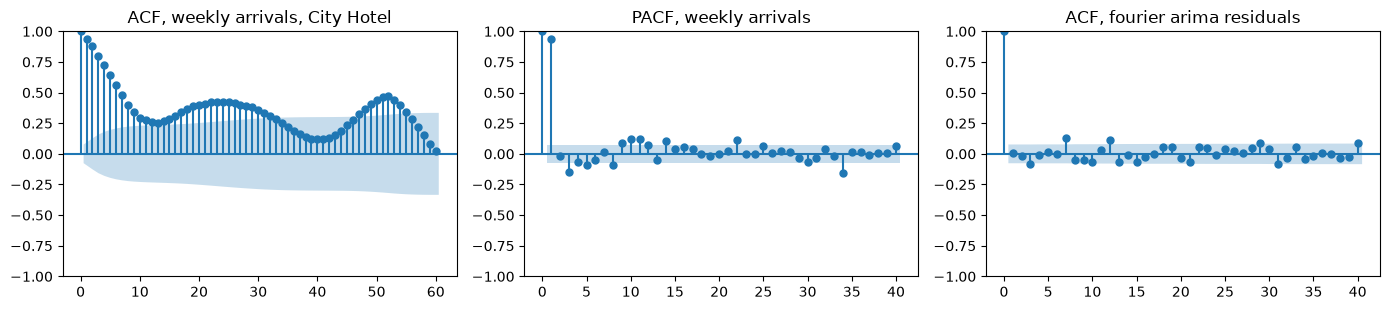

Resort Hotel diagnostics {"weeks": 665, "adf_p_level": 0.2126, "adf_p_yearly_diff": 0.0779, "ljung_box_p_lag8": 0.0611, "ljung_box_p_lag26": 0.0707, "resid_acf1": -0.004}


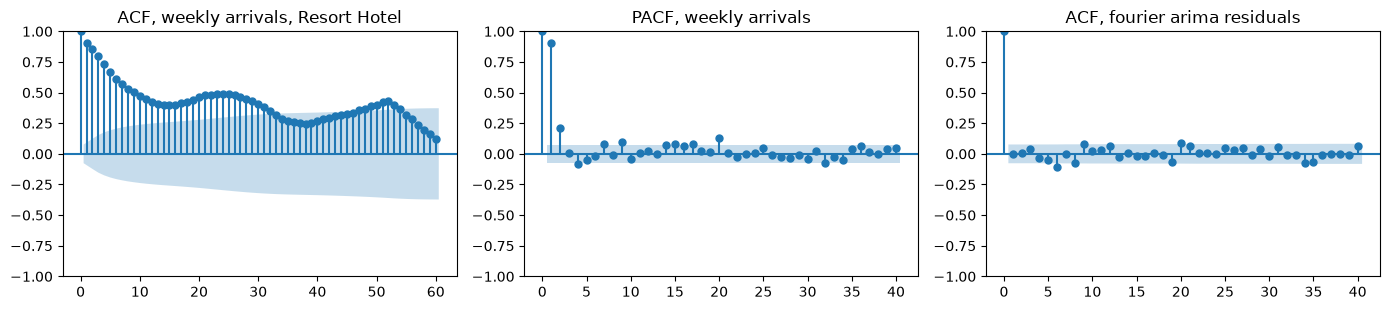

mean mape over the last 52 origins with at least 52 weeks of history, 8 weeks ahead
hotel         method               
City Hotel    ensemble                 0.0527
              ets                      0.0881
              fourier_arima            0.0715
              gbm_direct               0.0343
              mean_ets_pickup          0.0492
              pickup                   0.0491
              seasonal_naive           0.0456
              seasonal_naive_growth    0.0502
Resort Hotel  ensemble                 0.0700
              ets                      0.0957
              fourier_arima            0.1038
              gbm_direct               0.0462
              mean_ets_pickup          0.0662
              pickup                   0.0873
              seasonal_naive           0.0567
              seasonal_naive_growth    0.0653


In [26]:
weekly, frame = weekly_arrivals(PARQUET_PATH)
weekly = weekly[weekly["week"] <= origin_date]
print("forecast origin " + str(origin_date.date()) + ", last complete week " + str(weekly["week"].max().date()))
diagnostics = {}
for hotel in ["City Hotel", "Resort Hotel"]:
    series = weekly[weekly["hotel"] == hotel].set_index("week")["arrivals"].astype(float)
    adf_level = adfuller(series.values, autolag="AIC")
    adf_diff = adfuller(series.diff(52).dropna().values, autolag="AIC") if len(series) > 65 else (None, float("nan"))
    fa = SARIMAX(series.values, exog=fourier_terms(series.index).values, order=(1, 0, 1), trend="c", enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=300)
    lb = acorr_ljungbox(fa.resid[10:], lags=[8, 26], return_df=True)
    diagnostics[hotel] = {"weeks": int(len(series)), "adf_p_level": round(float(adf_level[1]), 4), "adf_p_yearly_diff": round(float(adf_diff[1]), 4), "ljung_box_p_lag8": round(float(lb["lb_pvalue"].iloc[0]), 4), "ljung_box_p_lag26": round(float(lb["lb_pvalue"].iloc[1]), 4), "resid_acf1": round(float(acf(fa.resid[10:], nlags=1)[1]), 3)}
    print(hotel + " diagnostics " + json.dumps(diagnostics[hotel]))
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.2))
    plot_acf(series.values, lags=min(60, len(series) - 2), ax=axes[0], title="ACF, weekly arrivals, " + hotel)
    plot_pacf(series.values, lags=min(40, len(series) // 2 - 1), ax=axes[1], method="ywm", title="PACF, weekly arrivals")
    plot_acf(fa.resid[10:], lags=min(40, len(series) - 12), ax=axes[2], title="ACF, fourier arima residuals")
    plt.tight_layout()
    plt.show()
results = pd.concat([backtest(weekly, frame, hotel, min_history_weeks, horizon_weeks) for hotel in ["City Hotel", "Resort Hotel"]])
summary = results.groupby(["hotel", "method"])["mape"].mean().round(4)
origins_used = int(results.groupby("hotel")["origin"].nunique().min())
print("mean mape over the last " + str(origins_used) + " origins with at least " + str(min_history_weeks) + " weeks of history, " + str(horizon_weeks) + " weeks ahead")
print(summary.to_string())

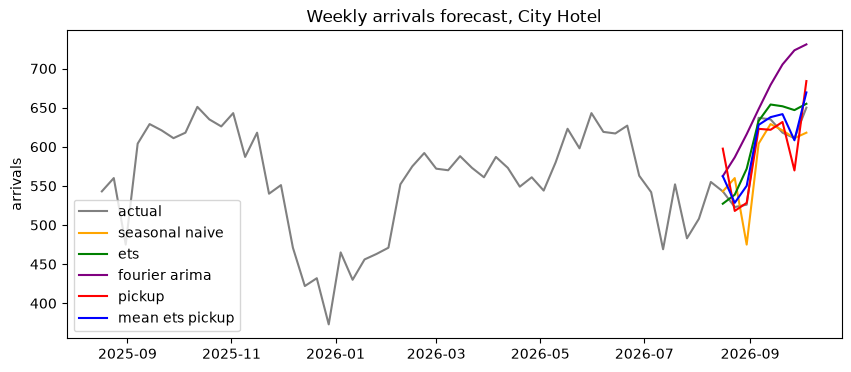

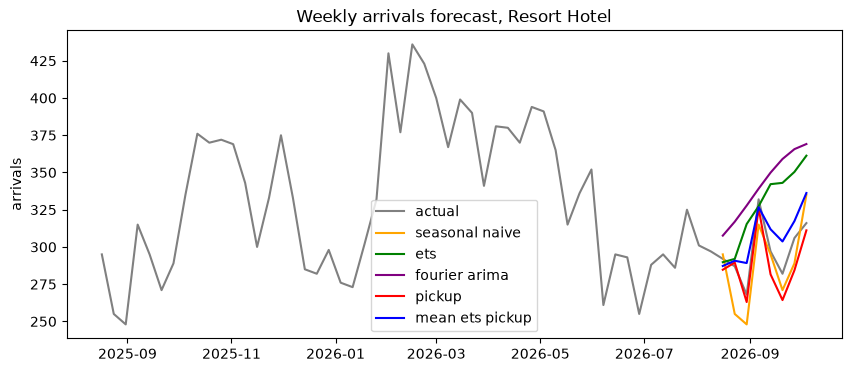

In [27]:
plot_last_origin(weekly, frame, "City Hotel", horizon_weeks)
plot_last_origin(weekly, frame, "Resort Hotel", horizon_weeks)

mean mape over the backtest origins, in sample against 8 weeks ahead
                                    train_mape  test_mape
hotel        method                                      
City Hotel   ets                        0.0511     0.0881
             fourier_arima              0.0496     0.0715
             gbm_direct                 0.0285     0.0343
             seasonal_naive             0.0357     0.0456
             seasonal_naive_growth      0.0357     0.0502
Resort Hotel ets                        0.0659     0.0957
             fourier_arima              0.0729     0.1038
             gbm_direct                 0.0406     0.0462
             seasonal_naive             0.0617     0.0567
             seasonal_naive_growth      0.0617     0.0653


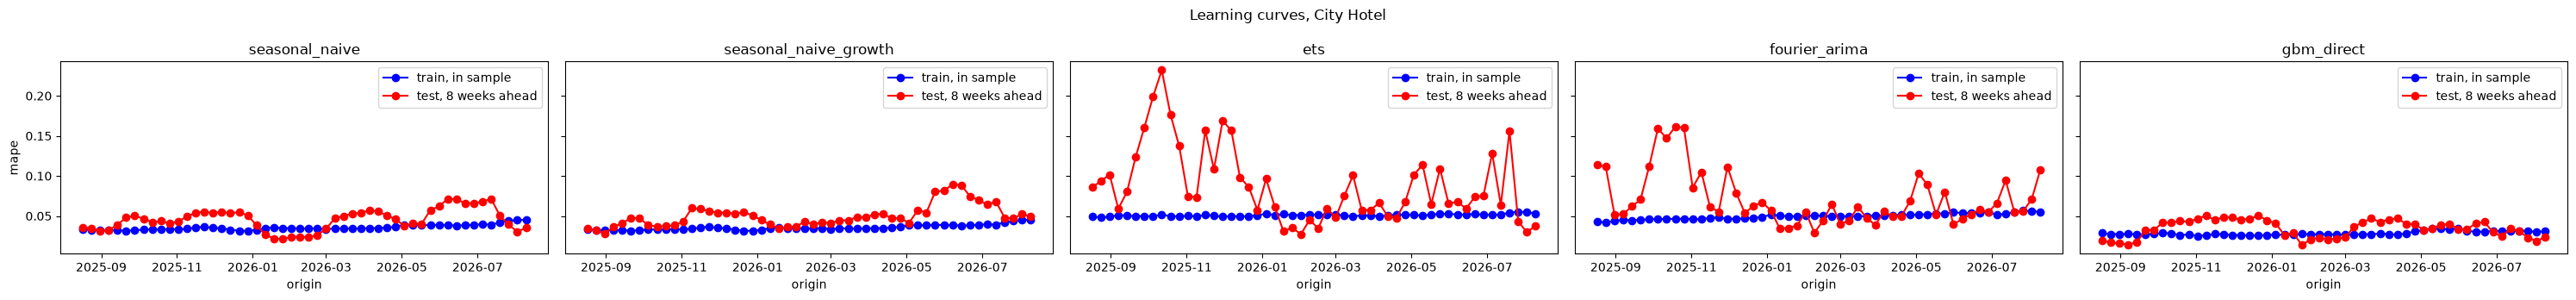

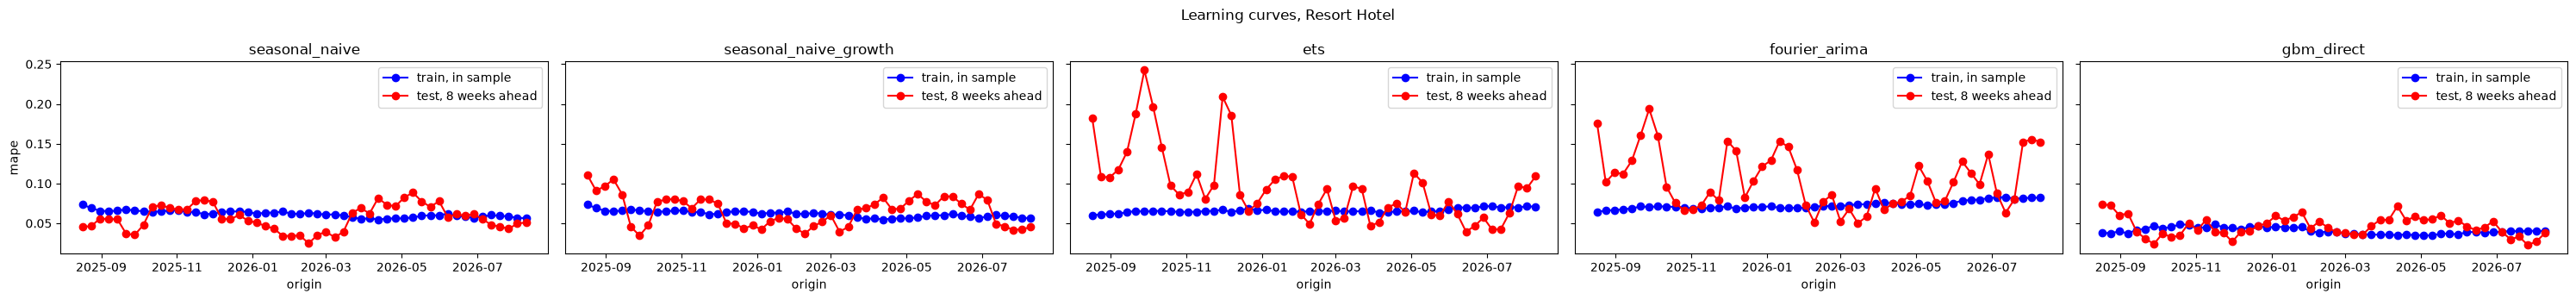

In [28]:
curve = pd.concat([learning_curve(weekly, frame, hotel, min_history_weeks, horizon_weeks) for hotel in ["City Hotel", "Resort Hotel"]], ignore_index=True)
print("mean mape over the backtest origins, in sample against " + str(horizon_weeks) + " weeks ahead")
print(curve.groupby(["hotel", "method"])[["train_mape", "test_mape"]].mean().round(4).to_string())
for hotel in ["City Hotel", "Resort Hotel"]:
    plot_learning_curve(curve, hotel, horizon_weeks)

In [29]:
methods = {"seasonal_naive": forecast_seasonal_naive, "seasonal_naive_growth": forecast_seasonal_naive_growth, "ets": forecast_ets, "fourier_arima": forecast_fourier_arima, "pickup": forecast_pickup, "mean_ets_pickup": forecast_mean_ets_pickup, "ensemble": forecast_ensemble}
forecasts = {}
for hotel in ["City Hotel", "Resort Hotel"]:
    series = weekly[weekly["hotel"] == hotel].reset_index(drop=True)
    weeks = [series["week"].iloc[-1] + pd.Timedelta(weeks=i + 1) for i in range(horizon_weeks)]
    otb, ratios = pickup_inputs(frame, hotel, series["week"].iloc[-1], weeks)
    chosen = summary.loc[hotel].idxmin() if origins_used >= min_origins else "ets"
    if chosen == "gbm_direct":
        grows = gbm_rows(series, otb_table(frame, hotel, horizon_weeks), horizon_weeks)
        grows["hotel_code"] = 1 if hotel == "City Hotel" else 0
        values = forecast_gbm(grows, fit_gbm(grows, len(series)), len(series), horizon_weeks)
    else:
        values = methods[chosen](series, horizon_weeks, {"otb": otb, "ratios": ratios})
    forecasts[hotel] = {"method": chosen, "origin": str(series["week"].iloc[-1].date()), "history_weeks": int(len(series)), "origins_in_backtest": origins_used, "weeks": [str((w + pd.Timedelta(days=replay_shift_days)).date()) for w in weeks], "arrivals": [round(float(v), 1) for v in values], "mape_backtest": float(summary.loc[(hotel, chosen)]), "mape_seasonal_naive": float(summary.loc[(hotel, "seasonal_naive")])}
    print(hotel + " chosen " + chosen + ", next weeks " + str(forecasts[hotel]["arrivals"]))

City Hotel chosen gbm_direct, next weeks [644.9, 646.6, 645.5, 625.7, 610.2, 588.8, 539.7, 539.9]


Resort Hotel chosen gbm_direct, next weeks [355.5, 363.1, 370.4, 358.1, 340.3, 308.3, 314.7, 329.8]


In [30]:
index = pageview_index(PAGEVIEWS_PATH)
nights = eurostat_nights(EUROSTAT_PATH, "PT")
frame = nowcast_frame(nights, index)
test_fit = fit_pageview_test(frame, "2024-01-01")
print("yearly growth of nights on yearly change of pageview index, months since 2024: coefficient " + str(round(test_fit.params["index_change"], 3)) + ", p value " + str(round(test_fit.pvalues["index_change"], 3)) + ", r2 " + str(round(test_fit.rsquared, 3)))
growth, nowcast = fit_nowcast(frame, growth_window)
nowcast_mape, naive_mape = nowcast_backtest(frame, growth_window)
print("mean growth of the last " + str(growth_window) + " published months " + str(round(growth, 4)))
print("rolling mape last 12 published months, trend nowcast " + str(round(nowcast_mape, 4)) + ", same month last year " + str(round(naive_mape, 4)))
print("nowcast of unpublished months")
print(nowcast.round(0).to_string())

yearly growth of nights on yearly change of pageview index, months since 2024: coefficient -0.048, p value 0.32, r2 0.034
mean growth of the last 6 published months 0.0179
rolling mape last 12 published months, trend nowcast 0.0101, same month last year 0.024
nowcast of unpublished months
month
2026-08-01    8758302.0
2026-09-01    7086310.0


In [31]:
export(summary, nowcast, growth, test_fit, nowcast_mape, naive_mape, forecasts, diagnostics, curve)

saved /srv/data/models/forecast.json
